# Conceptos de Circuitos: Valores Medio, Eficaz y Factor de Forma

Este notebook presenta un resumen teórico y práctico de los conceptos de **Valor Medio**, **Valor Eficaz (RMS)** y **Factor de Forma** para diferentes formas de onda periódicas, implementado en Python utilizando cálculo simbólico (`sympy`) y numérico (`numpy`).

## 1. Fundamentos Teóricos

### Valor Medio ($V_{med}$)
El valor medio de una función periódica $y(t)$ con período $T$ representa el promedio algebraico del área bajo la curva en un ciclo completo:

$$V_{med} = \frac{1}{T} \int_{0}^{T} y(t) \, dt$$

*Nota: Para señales alternas simétricas puras (como una senoidal completa), el valor medio en un período es cero. En esos casos, suele calcularse el valor medio del semiciclo positivo o de la señal rectificada.*

### Valor Eficaz o RMS ($V_{ef}$ o $V_{rms}$)
El valor eficaz representa el valor de una corriente continua equivalente que disiparía la misma potencia en forma de calor al circular por una resistencia pura $R$:

$$V_{ef} = \sqrt{\frac{1}{T} \int_{0}^{T} [y(t)]^2 \, dt}$$

### Factor de Forma ($k_f$)
El factor de forma es la relación entre el valor eficaz y el valor medio (usualmente considerando el valor medio absoluto o del semiciclo para evitar indeterminaciones por valores medios nulos):

$$k_f = \frac{V_{ef}}{V_{med}}$$

## 2. Configuración del Entorno y Definición de Funciones
Utilizaremos `sympy` para obtener las expresiones analíticas exactas y evaluar numéricamente.

🌊 1. Onda Senoidal (Semiciclo Positivo)Para la onda senoidal, se grafica el ciclo completo pero se sombrea el semiciclo positivo (de $0$ a $\pi$), que es el área que define matemáticamente el valor medio práctico de la señal ($0.637 \cdot A$). También se traza la línea continua del valor eficaz ($0.707 \cdot A$).

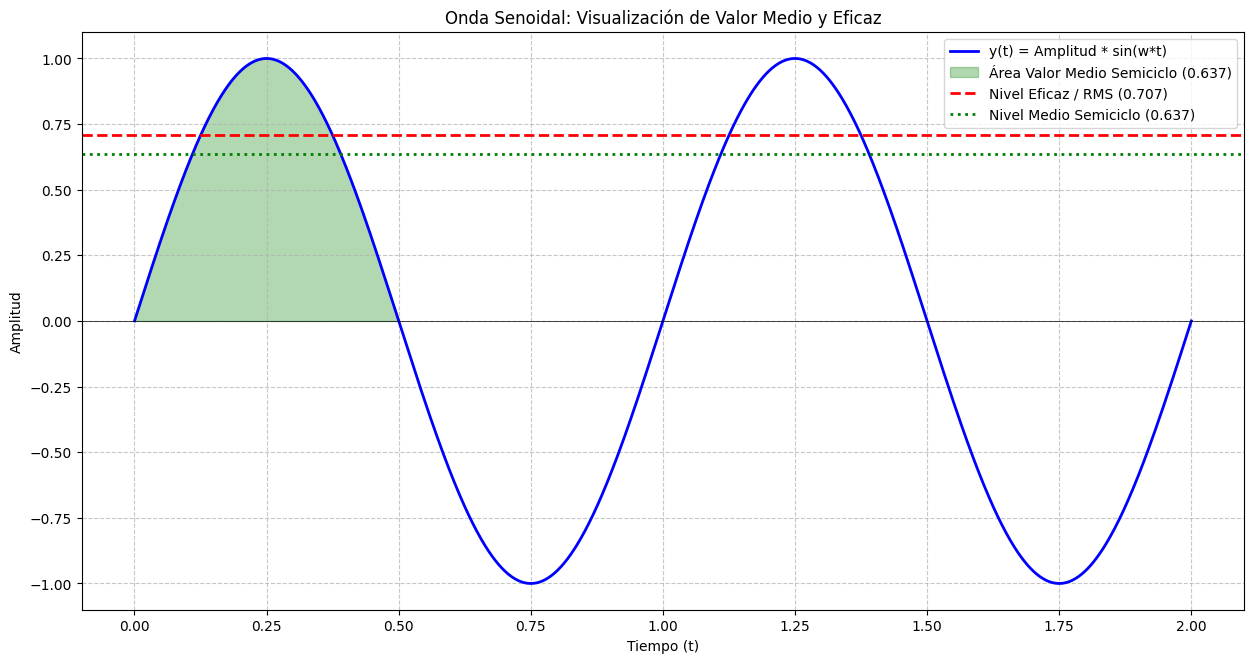

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
t = np.linspace(0, 2, 1000)      # 2 ciclos completos (Frecuencia = 1 Hz)
y = np.sin(2 * np.pi * t)
v_ef = 1 / np.sqrt(2)
v_med_semi = 2 / np.pi

plt.figure(figsize=(15, 7.5))
plt.plot(t, y, 'b-', label='y(t) = Amplitud * sin(w*t)', linewidth=2)

# Colorear el área del semiciclo positivo (Concepto de Valor Medio)
t_semi = np.linspace(0, 0.5, 500)
y_semi = np.sin(2 * np.pi * t_semi)
plt.fill_between(t_semi, y_semi, color='green', alpha=0.3, label=f'Área Valor Medio Semiciclo ({v_med_semi:.3f})')

# Líneas de nivel para comparar
plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'Nivel Eficaz / RMS ({v_ef:.3f})')
plt.axhline(y=v_med_semi, color='green', linestyle=':', linewidth=2, label=f'Nivel Medio Semiciclo ({v_med_semi:.3f})')

plt.title('Onda Senoidal: Visualización de Valor Medio y Eficaz')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

## 3. Análisis de Diferentes Formas de Onda

### Caso A: Onda Senoidal Pura
Para una onda $y(t) = A \sin(\omega t)$, donde $\omega = 2\pi/T$.

⏹️ 2. Onda Cuadrada SimétricaEn la onda cuadrada, el valor absoluto medio y el valor eficaz son idénticos a la amplitud máxima ($A = 1$). El gráfico colorea tanto el semiciclo positivo como el negativo (en valor absoluto) para demostrar que la energía integrada en todo momento llena perfectamente el nivel eficaz continuo.

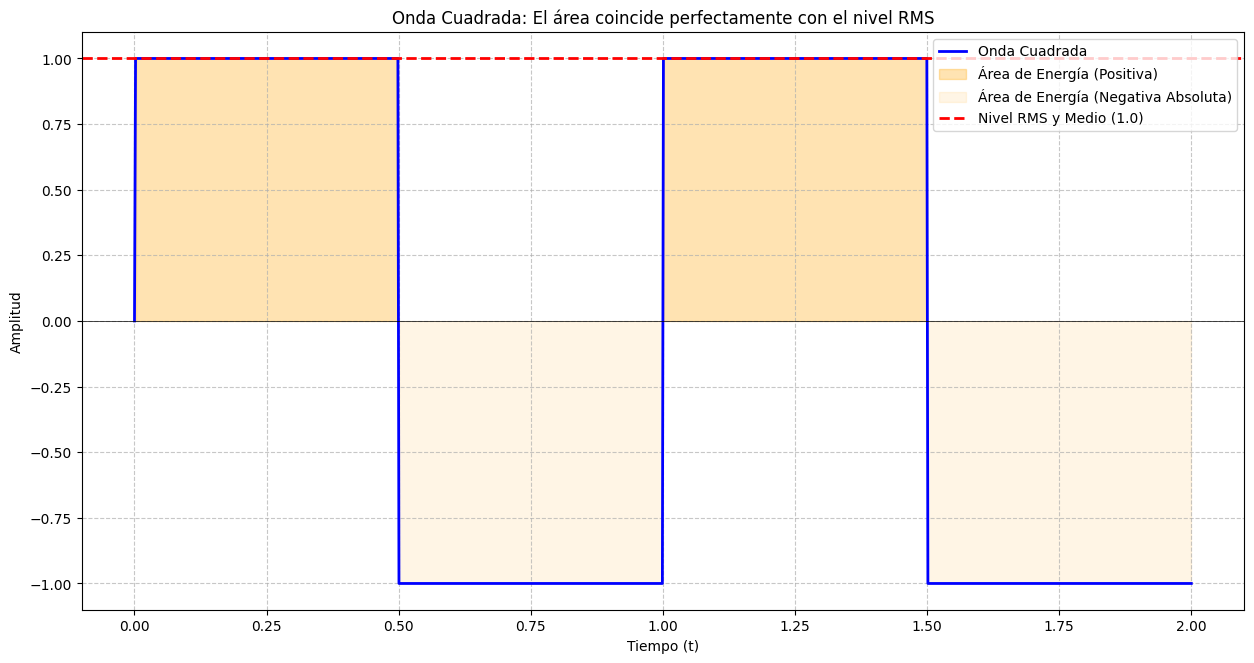

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 1000)
y = np.sign(np.sin(2 * np.pi * t))
v_ef = 1.0
v_med_abs = 1.0

plt.figure(figsize=(15, 7.5))
plt.plot(t, y, 'b-', label='Onda Cuadrada', linewidth=2)

# Colorear las áreas bajo la curva (en valor absoluto)
plt.fill_between(t, y, where=(y > 0), color='orange', alpha=0.3, label='Área de Energía (Positiva)')
plt.fill_between(t, y, where=(y < 0), color='orange', alpha=0.1, label='Área de Energía (Negativa Absoluta)')

# Línea de nivel eficaz/medio
plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'Nivel RMS y Medio ({v_ef:.1f})')

plt.title('Onda Cuadrada: El área coincide perfectamente con el nivel RMS')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

🔺 3. Onda TriangularPara la onda triangular, se observa claramente cómo el valor medio del semiciclo se sitúa exactamente a la mitad del pico ($0.5 \cdot A$), mientras que el valor eficaz (RMS) se posiciona un poco más arriba ($\approx 0.577 \cdot A$) debido al peso que tienen los valores más altos al elevarse al cuadrado en la integral del cálculo eficaz.

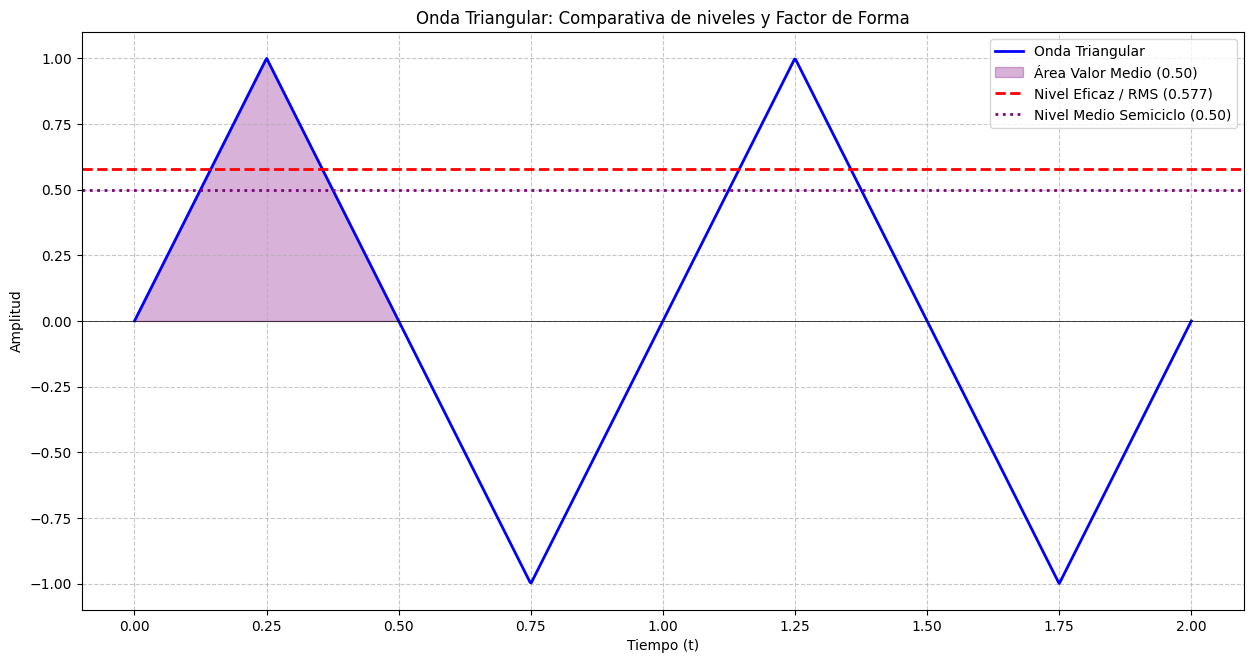

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

t = np.linspace(0, 2, 1000)
# Genera onda triangular simétrica desplazada para tener semiciclo positivo definido
y = signal.sawtooth(2 * np.pi * t + np.pi/2, 0.5)
v_ef = 1 / np.sqrt(3)
v_med_semi = 0.5

plt.figure(figsize=(15, 7.5))
plt.plot(t, y, 'b-', label='Onda Triangular', linewidth=2)

# Colorear el triángulo del semiciclo positivo
t_tri = np.linspace(0, 0.5, 250)
y_tri = signal.sawtooth(2 * np.pi * t_tri + np.pi/2, 0.5)
plt.fill_between(t_tri, y_tri, where=(y_tri > 0), color='purple', alpha=0.3, label=f'Área Valor Medio ({v_med_semi:.2f})')

# Líneas de nivel
plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'Nivel Eficaz / RMS ({v_ef:.3f})')
plt.axhline(y=v_med_semi, color='purple', linestyle=':', linewidth=2, label=f'Nivel Medio Semiciclo ({v_med_semi:.2f})')

plt.title('Onda Triangular: Comparativa de niveles y Factor de Forma')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

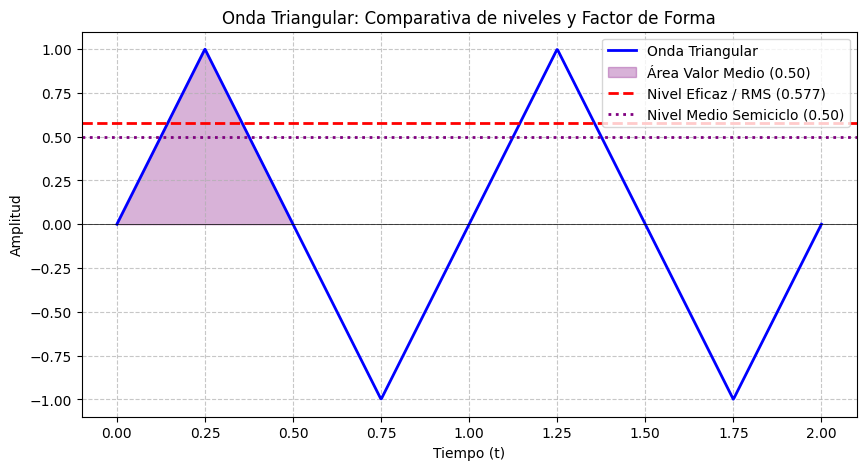

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

t = np.linspace(0, 2, 1000)
# Genera onda triangular simétrica desplazada para tener semiciclo positivo definido
y = signal.sawtooth(2 * np.pi * t + np.pi/2, 0.5)
v_ef = 1 / np.sqrt(3)
v_med_semi = 0.5

plt.figure(figsize=(10, 5))
plt.plot(t, y, 'b-', label='Onda Triangular', linewidth=2)

# Colorear el triángulo del semiciclo positivo
t_tri = np.linspace(0, 0.5, 250)
y_tri = signal.sawtooth(2 * np.pi * t_tri + np.pi/2, 0.5)
plt.fill_between(t_tri, y_tri, where=(y_tri > 0), color='purple', alpha=0.3, label=f'Área Valor Medio ({v_med_semi:.2f})')

# Líneas de nivel
plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'Nivel Eficaz / RMS ({v_ef:.3f})')
plt.axhline(y=v_med_semi, color='purple', linestyle=':', linewidth=2, label=f'Nivel Medio Semiciclo ({v_med_semi:.2f})')

plt.title('Onda Triangular: Comparativa de niveles y Factor de Forma')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

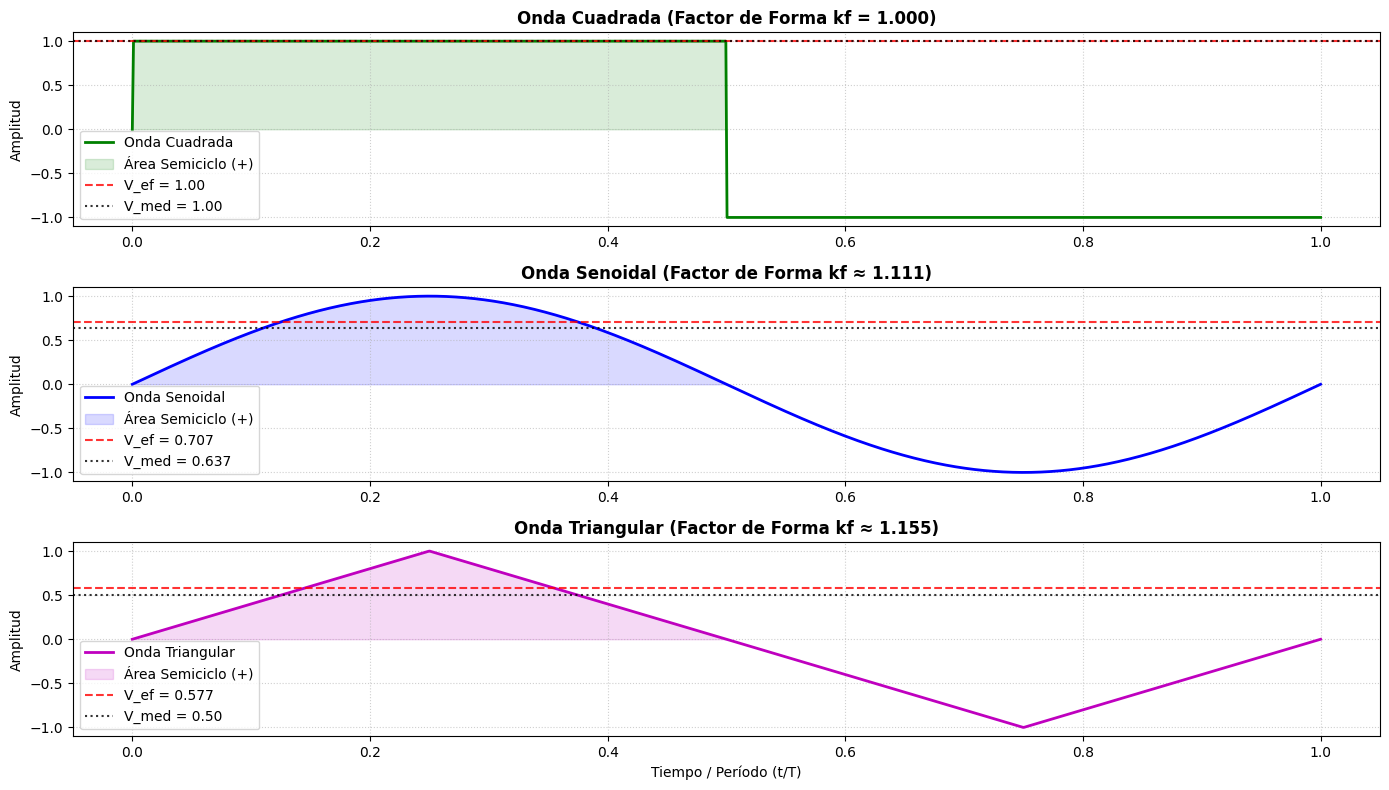

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Configuración de la simulación (1 ciclo completo para claridad visual)
t = np.linspace(0, 1, 1000)
amplitud = 1.0

# 2. Definición de las tres señales
y_cuad = amplitud * np.sign(np.sin(2 * np.pi * t))
y_sen  = amplitud * np.sin(2 * np.pi * t)
y_tri  = amplitud * signal.sawtooth(2 * np.pi * t + np.pi/2, 0.5)

# 3. Valores de cálculo para el semiciclo positivo (t de 0 a 0.5)
t_semi = t[t <= 0.5]
y_sen_semi = y_sen[t <= 0.5]

# Métricas teóricas
v_ef_cuad, v_med_cuad = 1.0, 1.0
v_ef_sen,  v_med_sen  = 1 / np.sqrt(2), 2 / np.pi
v_ef_tri,  v_med_tri  = 1 / np.sqrt(3), 0.5

# 4. Creación del gráfico comparativo
plt.figure(figsize=(14, 8))

# --- Gráfico 1: Onda Cuadrada ---
plt.subplot(3, 1, 1)
plt.plot(t, y_cuad, 'g-', linewidth=2, label='Onda Cuadrada')
plt.fill_between(t_semi, y_cuad[t <= 0.5], color='g', alpha=0.15, label='Área Semiciclo (+)')
plt.axhline(y=v_ef_cuad, color='red', linestyle='--', alpha=0.8, label=f'V_ef = {v_ef_cuad:.2f}')
plt.axhline(y=v_med_cuad, color='black', linestyle=':', alpha=0.8, label=f'V_med = {v_med_cuad:.2f}')
# Corregido: Usamos texto plano para evitar conflictos con el parseador de expresiones de matplotlib
plt.title('Onda Cuadrada (Factor de Forma kf = 1.000)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.ylabel('Amplitud')

# --- Gráfico 2: Onda Senoidal ---
plt.subplot(3, 1, 2)
plt.plot(t, y_sen, 'b-', linewidth=2, label='Onda Senoidal')
plt.fill_between(t_semi, y_sen_semi, color='b', alpha=0.15, label='Área Semiciclo (+)')
plt.axhline(y=v_ef_sen, color='red', linestyle='--', alpha=0.8, label=f'V_ef = {v_ef_sen:.3f}')
plt.axhline(y=v_med_sen, color='black', linestyle=':', alpha=0.8, label=f'V_med = {v_med_sen:.3f}')
plt.title('Onda Senoidal (Factor de Forma kf ≈ 1.111)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.ylabel('Amplitud')

# --- Gráfico 3: Onda Triangular ---
plt.subplot(3, 1, 3)
plt.plot(t, y_tri, 'm-', linewidth=2, label='Onda Triangular')
plt.fill_between(t_semi, y_tri[t <= 0.5], color='m', alpha=0.15, label='Área Semiciclo (+)')
plt.axhline(y=v_ef_tri, color='red', linestyle='--', alpha=0.8, label=f'V_ef = {v_ef_tri:.3f}')
plt.axhline(y=v_med_tri, color='black', linestyle=':', alpha=0.8, label=f'V_med = {v_med_tri:.2f}')
plt.title('Onda Triangular (Factor de Forma kf ≈ 1.155)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.xlabel('Tiempo / Período (t/T)')
plt.ylabel('Amplitud')

plt.tight_layout()
plt.show()

### Caso B: Onda Cuadrada Simétrica
Onda que vale $A$ de $0$ a $T/2$, y $-A$ de $T/2$ a $T$.

In [ ]:
# Definimos mediante tramos (Piecewise)
y_cuad = sp.Piecewise((A, t < T/2), (-A, True))

# Valor medio absoluto
v_med_abs = A

med, med_calc, ef, ff = calcular_metricas(y_cuad, t, T, valor_medio_alternativo=v_med_abs)

print("=== ONDA CUADRADA SIMÉTRICA ===")
print(f"Valor Medio: {med}")
print(f"Valor Eficaz (RMS): {ef}")
print(f"Factor de Forma: {ff}")

=== ONDA CUADRADA SIMÉTRICA ===
Valor Medio: 0
Valor Eficaz (RMS): A
Factor de Forma: 1


### Caso C: Onda Triangular
Onda que sube linealmente desde $-A$ hasta $A$ en medio período, y baja en el siguiente medio período.

## 4. Visualización Gráfica de las Ondas
A continuación, se grafican las ondas con sus respectivos niveles eficaces y medios (en valor absoluto o semiciclo).

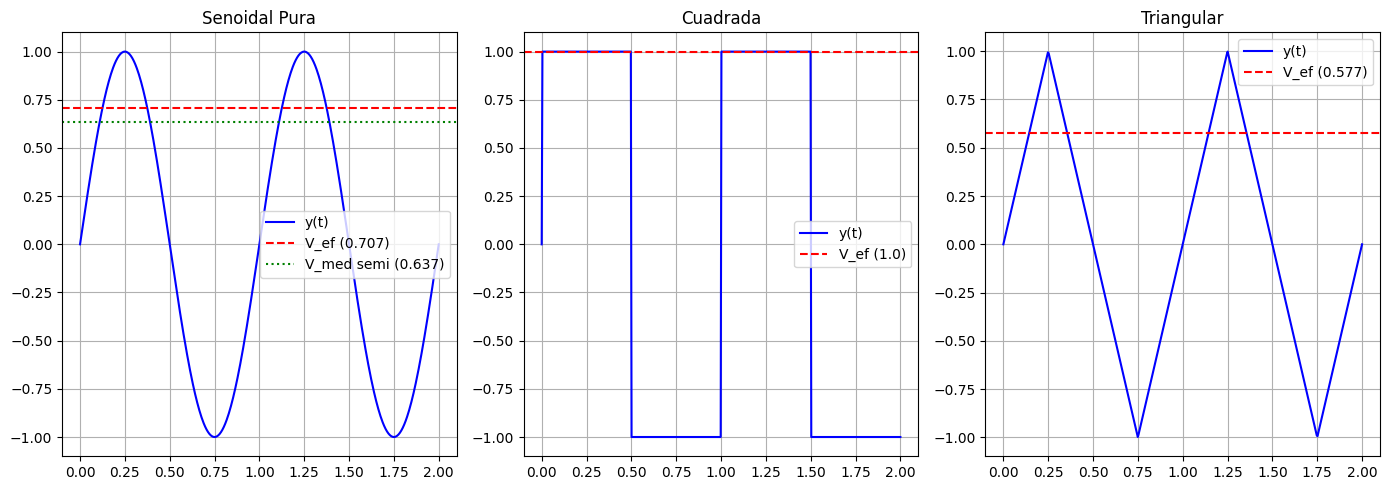

In [ ]:
t_arr = np.linspace(0, 2, 500)

plt.figure(figsize=(14, 5))

# Senoidal
plt.subplot(1, 3, 1)
plt.plot(t_arr, np.sin(2 * np.pi * t_arr), 'b', label='y(t)')
plt.axhline(y=1/np.sqrt(2), color='r', linestyle='--', label='V_ef (0.707)')
plt.axhline(y=2/np.pi, color='g', linestyle=':', label='V_med semi (0.637)')
plt.title('Senoidal Pura')
plt.grid(True)
plt.legend()

# Cuadrada
plt.subplot(1, 3, 2)
plt.plot(t_arr, np.sign(np.sin(2 * np.pi * t_arr)), 'b', label='y(t)')
plt.axhline(y=1, color='r', linestyle='--', label='V_ef (1.0)')
plt.title('Cuadrada')
plt.grid(True)
plt.legend()

# Triangular
plt.subplot(1, 3, 3)
from scipy import signal
plt.plot(t_arr, signal.sawtooth(2 * np.pi * t_arr + np.pi/2, 0.5), 'b', label='y(t)')
plt.axhline(y=1/np.sqrt(3), color='r', linestyle='--', label='V_ef (0.577)')
plt.title('Triangular')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

--- Semiciclo Senoidal ---
Valor Medio Calculado: 0.6366
Valor Eficaz (RMS) Calculado: 0.7071
Factor de Forma: 1.1107


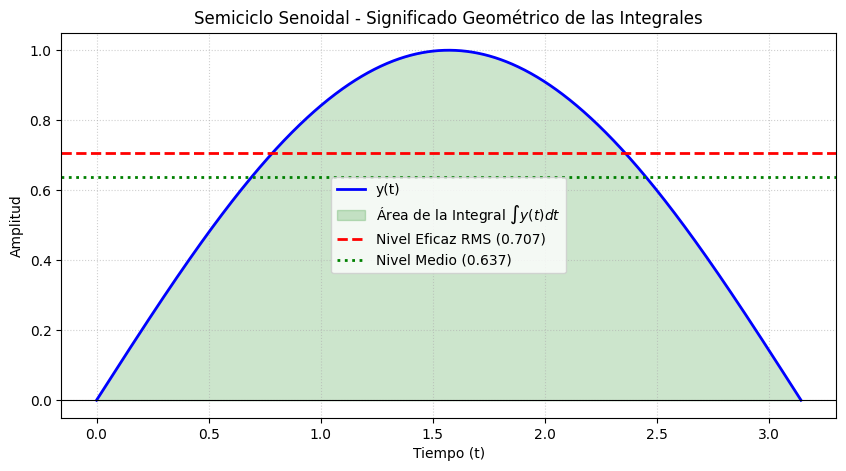

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def calcular_y_graficar_simbolico(expr_sympy, var_t, T_valor, titulo="Señal Analizada"):
    """
    Calcula analíticamente e imprime/grafica las áreas de integración.
    expr_sympy: expresión de sympy (ej: A * sp.sin(t))
    var_t: la variable simbólica del tiempo t
    T_valor: el valor numérico del período para el gráfico
    """
    # 1. Cálculos analíticos con SymPy
    integral_med = sp.integrate(expr_sympy, (var_t, 0, T_valor))
    v_med = float(integral_med / T_valor)

    integral_ef = sp.integrate(expr_sympy**2, (var_t, 0, T_valor))
    v_ef = float(sp.sqrt(integral_ef / T_valor))

    print(f"--- {titulo} ---")
    print(f"Valor Medio Calculado: {v_med:.4f}")
    print(f"Valor Eficaz (RMS) Calculado: {v_ef:.4f}")
    print(f"Factor de Forma: {(v_ef/v_med):.4f}" if v_med != 0 else "Factor de Forma: Indeterminado (V_med = 0)")

    # 2. Preparación de datos numéricos para Matplotlib
    f_num = sp.lambdify(var_t, expr_sympy, "numpy")
    t_v = np.linspace(0, T_valor, 1000)
    y_v = f_num(t_v)

    # Si la función devuelve un único valor escalar (como una constante), expandimos el array
    if isinstance(y_v, (int, float)):
        y_v = np.full_like(t_v, y_v)

    # 3. Construcción del Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(t_v, y_v, 'b-', linewidth=2, label='y(t)')

    # Sombreado del área bajo la curva (Integral del Valor Medio)

    # Solución: Agrega una 'r' antes de abrir las comillas para indicar texto crudo (raw string)
    plt.fill_between(t_v, y_v, color='green', alpha=0.2, label=r'Área de la Integral $\int y(t)dt$')

    # Líneas de nivel de los resultados
    plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'Nivel Eficaz RMS ({v_ef:.3f})')
    if v_med != 0:
        plt.axhline(y=v_med, color='green', linestyle=':', linewidth=2, label=f'Nivel Medio ({v_med:.3f})')

    plt.title(f'{titulo} - Significado Geométrico de las Integrales')
    plt.xlabel('Tiempo (t)')
    plt.ylabel('Amplitud')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.show()

# === EJEMPLO DE USO ===
t = sp.Symbol('t', positive=True)
# Analicemos por ejemplo el semiciclo positivo de una senoidal (período T = pi)
y_t = sp.sin(t)
calcular_y_graficar_simbolico(y_t, t, T_valor=np.pi, titulo="Semiciclo Senoidal")

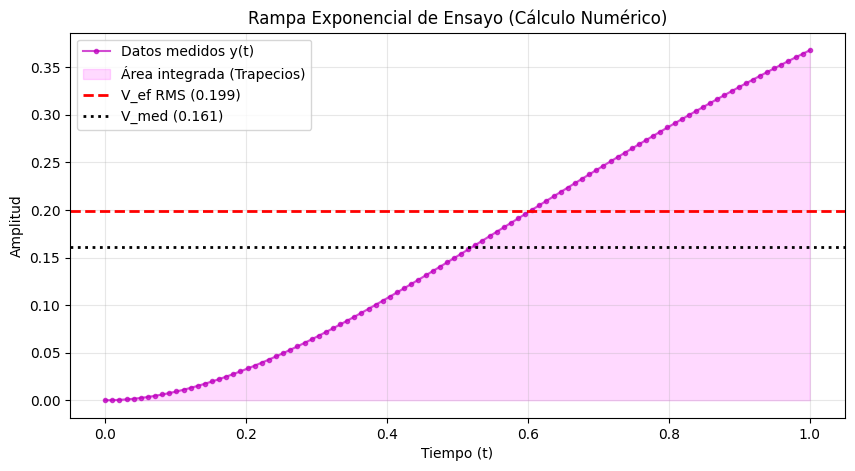

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

def calcular_y_graficar_numerico(vector_t, vector_y, titulo="Señal Muestreada"):
    T = vector_t[-1] - vector_t[0]

    # Integración numérica
    v_med = float((1 / T) * trapezoid(vector_y, vector_t))
    v_ef = float(np.sqrt((1 / T) * trapezoid(vector_y**2, vector_t)))

    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(vector_t, vector_y, 'm.-', label='Datos medidos y(t)', alpha=0.7)

    # Colorear la integral numérica elemental
    plt.fill_between(vector_t, vector_y, color='magenta', alpha=0.15, label='Área integrada (Trapecios)')

    # Niveles continuos equivalentes
    plt.axhline(y=v_ef, color='red', linestyle='--', linewidth=2, label=f'V_ef RMS ({v_ef:.3f})')
    plt.axhline(y=v_med, color='black', linestyle=':', linewidth=2, label=f'V_med ({v_med:.3f})')

    plt.title(f'{titulo} (Cálculo Numérico)')
    plt.xlabel('Tiempo (t)')
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.show()

# === EJEMPLO DE USO ===
# Creamos una señal arbitraria de tipo rampa exponencial amortiguada
t_datos = np.linspace(0, 1, 100)
y_datos = t_datos**2 * np.exp(-t_datos)

calcular_y_graficar_numerico(t_datos, y_datos, titulo="Rampa Exponencial de Ensayo")

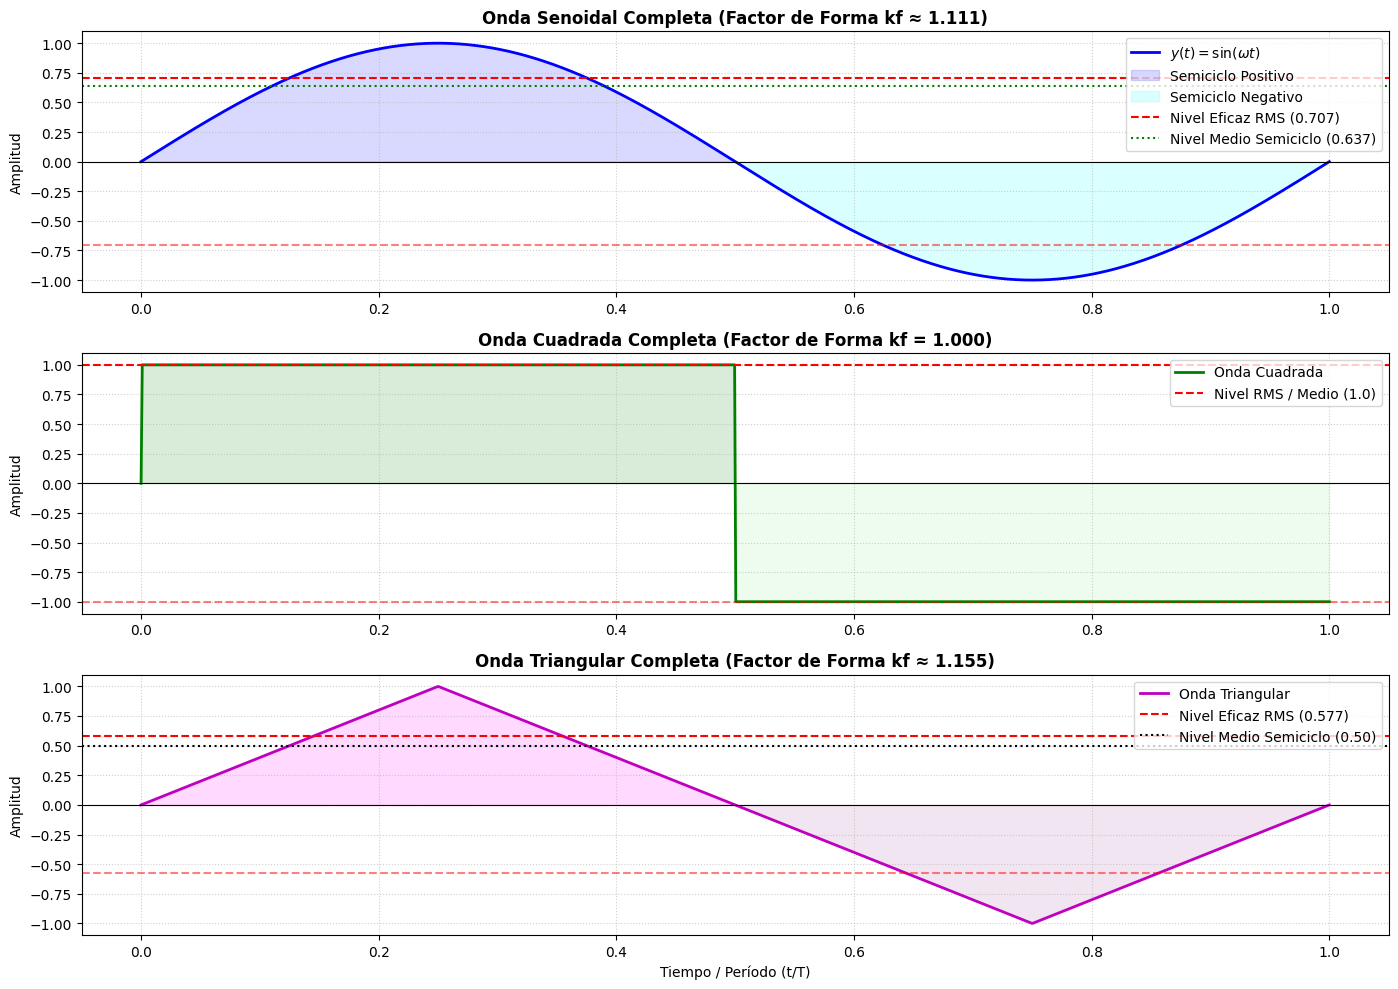

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Configuración de la simulación (1 ciclo completo: de 0 a 1)
t = np.linspace(0, 1, 1000)
amplitud = 1.0

# 2. Definición de las tres señales para el ciclo completo
y_sen  = amplitud * np.sin(2 * np.pi * t)
y_cuad = amplitud * np.sign(np.sin(2 * np.pi * t))
# Ajustamos la fase de la triangular para que empiece en cero, suba, baje y vuelva a cero
y_tri  = amplitud * signal.sawtooth(2 * np.pi * t + np.pi/2, 0.5)

# 3. Niveles métricos de referencia (basados en el semiciclo/valor absoluto)
v_ef_sen,  v_med_sen  = 1 / np.sqrt(2), 2 / np.pi
v_ef_cuad, v_med_cuad = 1.0, 1.0
v_ef_tri,  v_med_tri  = 1 / np.sqrt(3), 0.5

# 4. Construcción de las gráficas en paralelo para comparar el ciclo completo
plt.figure(figsize=(14, 10))

# --- PANEL 1: ONDA SENOIDAL ---
plt.subplot(3, 1, 1)
plt.plot(t, y_sen, 'b-', linewidth=2, label=r'$y(t) = \sin(\omega t)$')
# Sombreado de ambos semiciclos (el positivo y el negativo en valor absoluto para la integral media práctica)
plt.fill_between(t, y_sen, where=(y_sen > 0), color='blue', alpha=0.15, label='Semiciclo Positivo')
plt.fill_between(t, y_sen, where=(y_sen < 0), color='cyan', alpha=0.15, label='Semiciclo Negativo')
# Líneas de nivel
plt.axhline(y=v_ef_sen, color='red', linestyle='--', linewidth=1.5, label=f'Nivel Eficaz RMS ({v_ef_sen:.3f})')
plt.axhline(y=v_med_sen, color='green', linestyle=':', linewidth=1.5, label=f'Nivel Medio Semiciclo ({v_med_sen:.3f})')
plt.axhline(y=-v_ef_sen, color='red', linestyle='--', alpha=0.5)
plt.title('Onda Senoidal Completa (Factor de Forma kf ≈ 1.111)', fontsize=12, fontweight='bold')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.axhline(0, color='black', linewidth=0.8)

# --- PANEL 2: ONDA CUADRADA ---
plt.subplot(3, 1, 2)
plt.plot(t, y_cuad, 'g-', linewidth=2, label='Onda Cuadrada')
plt.fill_between(t, y_cuad, where=(y_cuad > 0), color='green', alpha=0.15)
plt.fill_between(t, y_cuad, where=(y_cuad < 0), color='lightgreen', alpha=0.15)
plt.axhline(y=v_ef_cuad, color='red', linestyle='--', linewidth=1.5, label=f'Nivel RMS / Medio ({v_ef_cuad:.1f})')
plt.axhline(y=-v_ef_cuad, color='red', linestyle='--', alpha=0.5)
plt.title('Onda Cuadrada Completa (Factor de Forma kf = 1.000)', fontsize=12, fontweight='bold')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.axhline(0, color='black', linewidth=0.8)

# --- PANEL 3: ONDA TRIANGULAR ---
plt.subplot(3, 1, 3)
plt.plot(t, y_tri, 'm-', linewidth=2, label='Onda Triangular')
plt.fill_between(t, y_tri, where=(y_tri > 0), color='magenta', alpha=0.15)
plt.fill_between(t, y_tri, where=(y_tri < 0), color='purple', alpha=0.1)
plt.axhline(y=v_ef_tri, color='red', linestyle='--', linewidth=1.5, label=f'Nivel Eficaz RMS ({v_ef_tri:.3f})')
plt.axhline(y=v_med_tri, color='black', linestyle=':', linewidth=1.5, label=f'Nivel Medio Semiciclo ({v_med_tri:.2f})')
plt.axhline(y=-v_ef_tri, color='red', linestyle='--', alpha=0.5)
plt.title('Onda Triangular Completa (Factor de Forma kf ≈ 1.155)', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo / Período (t/T)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

 Parámetros de las Señales SenoidalesFrecuencia ($f$): Número de ciclos por segundo (Hz).$$f = \frac{1}{T}$$Pulsación ($\omega$): Velocidad angular en rad/s.$$\omega = 2\pi f = \frac{2\pi}{T}$$Ecuación General: >$$v(t) = V_0 \cdot \operatorname{sen}(\omega t)$$